# **Beta Radiation Spectroscopy Experiment**

This notebook documents the Beta Radiation Spectroscopy experiment, which investigates the energy spectrum of beta radiation using a magnetic spectrometer. The experiment aims to:

- Determine the maximum energy of beta radiation
- Study the deflection of beta particles in a magnetic field
- Verify theoretical relationships for relativistic particles

## **Theoretical Background**
Beta radiation consists of electrons (\( $\beta^-$ \)) or positrons (\( $\beta^+$ \)) emitted during nuclear beta decay:

**For \( $\beta^-$ \) decay:**
$$ n \rightarrow p + e^- + \bar{\nu} $$

**For \( $\beta^+$ \) decay:**
$$ p \rightarrow n + e^+ + \nu $$

The energy spectrum of beta radiation is continuous because the decay energy is shared between the emitted electron/positron and the associated neutrino. The maximum energy (\( $E_{max}$ \)) is given by:

$$ E_{max} = 3E_h $$

where \( $E_h$ \) is the most probable energy, determined experimentally from the graph \( N = f(E) \).

## **Experimental Setup**

![Setup](imgs/image1.png)

The experimental apparatus consists of:
- An **electromagnet** providing a uniform magnetic field
- A **radiation detector** with a counting system
- A **high-voltage power supply** for calibration
- A **digital multimeter** to measure current through the magnet

Beta particles from a radioactive source (e.g., \( ^{90}Sr \) or \( ^{22}Na \)) are deflected in a circular trajectory due to the **Lorentz force**:

$$ F = q v B $$

This results in a circular motion with a radius given by:

$$ R = \frac{m v}{q B} $$

Using relativistic energy relations:

$$ E = \sqrt{(qRBc)^2 + (m_0 c^2)^2} - m_0 c^2 $$

where \( c \) is the speed of light, and \( m_0 \) is the rest mass of the electron.

## **Data Analysis & Calculations**
Using measured magnetic field values (B) and detected particle counts (N), we compute the kinetic energy of beta particles using the equation:

$$ E (keV) = (RBc)^2 / 1000 - 511 $$

Experimental values for \( E_h \) are determined graphically, and \( E_{max} \) is obtained using:

$$ E_{max} = 3E_h $$



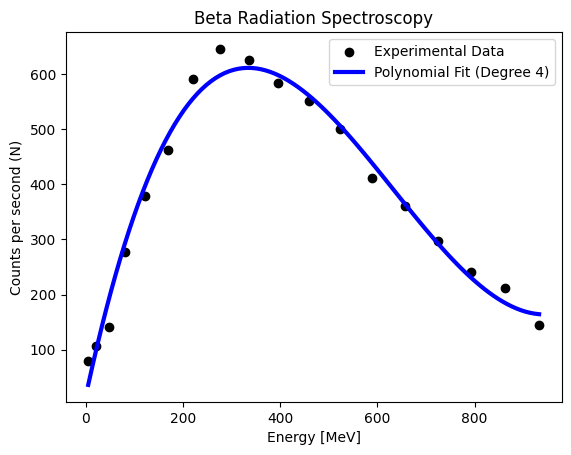


--- Beta Radiation Energy Analysis ---
Most Probable Energy (E_h): 3.000 MeV
Maximum Energy (E_max): 9.000 MeV
Polynomial Coefficients: [-4.39009669e-10  5.09086884e-06 -8.60178025e-03  4.11194472e+00
  1.35593626e+01]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def load_data(filename):
    """
    Load experimental data from a CSV file.
    
    Parameters:
        filename (str): Path to the CSV file.
    
    Returns:
        tuple: Arrays of energy (E) and detected counts (N).
    """
    data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    E = data[:, 2]  # Energy values (MeV)
    N = data[:, 3]  # Counts per second
    return E, N

def fit_polynomial(E, N, degree=4):
    """
    Fit a polynomial function to the experimental data.
    
    Parameters:
        E (array): Energy values.
        N (array): Detected counts.
        degree (int): Polynomial degree (default is 4).
    
    Returns:
        tuple: Polynomial coefficients and function.
    """
    coefs = np.polyfit(E, N, degree)
    poly_fit = np.poly1d(coefs)
    return coefs, poly_fit

def plot_data(E, N, poly_fit, degree):
    """
    Plot experimental data along with the polynomial fit.
    
    Parameters:
        E (array): Energy values.
        N (array): Detected counts.
        poly_fit (function): Fitted polynomial function.
        degree (int): Degree of polynomial fit.
    """
    x_range = np.linspace(min(E), max(E), 100)
    y_fit = poly_fit(x_range)

    plt.scatter(E, N, color='black', label='Experimental Data')
    plt.plot(x_range, y_fit, color='blue', linewidth=3, label=f'Polynomial Fit (Degree {degree})')

    plt.title('Beta Radiation Spectroscopy')
    plt.xlabel('Energy [MeV]')
    plt.ylabel('Counts per second (N)')
    plt.legend()
    plt.show()

def find_peak_energy(poly_fit):
    """
    Find the peak energy value in the polynomial fit.
    
    Parameters:
        poly_fit (function): Fitted polynomial function.
    
    Returns:
        float: Energy at the peak of the curve.
    """
    peak_result = minimize_scalar(lambda x: -poly_fit(x), bounds=(0, 3))
    return peak_result.x

def main():
    """Main function to process and analyze beta spectroscopy data."""
    
    # Load data
    E, N = load_data('data/values.csv')

    # Fit polynomial to data
    degree = 4  # Polynomial degree (adjustable)
    coefs, poly_fit = fit_polynomial(E, N, degree)

    # Plot results
    plot_data(E, N, poly_fit, degree)

    # Find the most probable energy (E_h)
    E_h = find_peak_energy(poly_fit)
    E_max = 3 * E_h  # Max energy (E_max = 3 * E_h)

    # Print results
    print("\n--- Beta Radiation Energy Analysis ---")
    print(f"Most Probable Energy (E_h): {E_h:.3f} MeV")
    print(f"Maximum Energy (E_max): {E_max:.3f} MeV")
    print(f"Polynomial Coefficients: {coefs}")

if __name__ == '__main__':
    main()
